# Single-molecule two-colour TIRF: acceptor binding kinetics from time traces

**Purpose.** Take iSMS-exported donor/acceptor time traces (`Dem-Dexc`, `Aem-Dexc`, one `.txt`
per molecule) and

1. detect **photobleaching** and **photoblinking** and exclude those frames,
2. correct for **donor leakage** and **gamma** (fall back to 0.09 / 0.7 if the data cannot support an estimate),
3. **normalise** each trace by its mean total fluorescence,
4. fit a **5-state HMM globally**, then re-fit every trace starting from the global parameters,
5. call the acceptor **bound** in states whose FRET is above background,
6. fit the **bound dwell-time** distribution with 1- and 2-component exponential (rate) models,
7. histogram the FRET of bound frames and fit a **Gaussian mixture**.

Everything runs on a laptop CPU. This notebook is **self-contained**: put it in a folder together with your
iSMS `Traces_*_pair<N>.txt` files and run all cells; every parsable `.txt` file in the folder is analysed.
Requires the default Anaconda packages plus `hmmlearn` (`pip install hmmlearn`). Only donor excitation is available (no ALEX), so see the notes at
the end for what that implies.

## 1. Imports

In [1]:
%matplotlib inline
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import hmmlearn  # noqa: F401
except ImportError as exc:
    raise ImportError("hmmlearn is required: run  pip install hmmlearn  (or conda install -c conda-forge hmmlearn) and restart the kernel") from exc

## 2. Parameters
Edit here (or override with `papermill -p NAME value`).

In [2]:
DATA_DIR = "."                     # folder holding the trace .txt files ("." = same folder as this notebook)
FILE_GLOB = "*.txt"
OUTPUT_DIR = "results"
FRAME_TIME_S = 1.0                 # seconds per frame -> rates are in 1/s (1.0 = rates per frame)
SEED = 0

# photobleaching / photoblinking detection
DARK_FRACTION = 0.4                # dark if total < dark + this * (bright - dark); 0.4 keeps high-FRET frames
MIN_DROP = 0.5                     # dark cluster must be < (1 - MIN_DROP) * bright cluster to count
MIN_BRIGHT_RUN = 3                 # bright runs shorter than this inside dark periods are spikes -> dark
MIN_BLEACH_FRAMES = 5              # terminal dark run needed to call photobleaching
PAD_FRAMES = 1                     # extra frames dropped on each side of a dark period
MIN_SNR = 8.0                      # bright level must exceed this x frame-to-frame noise
MIN_VALID_FRAMES = 50              # traces with fewer usable frames are rejected
MIN_SEGMENT_FRAMES = 5             # shortest contiguous stretch given to the HMM

# leakage / gamma (estimated from the data when enough events exist, otherwise defaults)
DEFAULT_LEAKAGE = 0.09
DEFAULT_GAMMA = 0.7
MIN_LEAK_TRACES = 3                # traces (each with >= 100 acceptor-free frames) needed for leakage
MIN_GAMMA_EVENTS = 5               # binding events needed for gamma
EVENT_SIGMA = 3.0                  # donor-down & acceptor-up threshold (robust sigmas)

# HMM
N_STATES = 5
GLOBAL_MAX_ITER = 200
INDIVIDUAL_MAX_ITER = 50
PRIOR_STRENGTH = 10.0              # weak pull of individual fits towards global parameters (pseudo-frames); 0 = off
BOUND_MARGIN = 0.10                # a state is "bound" if its FRET > FRET of lowest state + this

# dwell times / GMM
N_BOOT = 200                       # bootstrap resamples for dwell-model confidence intervals (0 = skip)
GMM_MAX_COMPONENTS = 4
GMM_N_COMPONENTS = None            # None = choose by BIC
N_EXAMPLE_TRACES = 5               # traces drawn in the example figure

## 3. Helper functions (self-contained)
Everything below is plain Python defined in this notebook; run these cells once. Conventions:

Conventions
-----------
* ``D``  = donor emission  under donor excitation  (``Dem-Dexc``)
* ``A``  = acceptor emission under donor excitation (``Aem-Dexc``)
* Leakage ``alpha``: fraction of the donor signal that bleeds into the acceptor channel,
  ``A_corr = A - alpha * D``.
* Gamma ``gamma``: detection-efficiency ratio, ``D_corr = gamma * D`` so that
  ``E = A_corr / (A_corr + gamma * D)`` and the total ``A_corr + gamma * D`` is conserved.
* Normalised signals: ``Dn = gamma*D / <total>``, ``An = A_corr / <total>`` with ``<total>``
  the mean of ``A_corr + gamma*D`` over the usable frames of that trace.  FRET of a point/state
  is ``An / (An + Dn)``.

In [3]:
from __future__ import annotations

import logging
import re
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
from scipy import ndimage, optimize

### Helpers: I/O

In [4]:
@dataclass
class Trace:
    name: str
    pair: int
    D: np.ndarray
    A: np.ndarray
    movie: str = ""

    @property
    def n_frames(self) -> int:
        return len(self.D)


def read_trace(path) -> Trace:
    """Read one iSMS ``Traces_*_pair<N>.txt`` export (5 header lines, then two columns)."""
    path = Path(path)
    with open(path) as fh:
        header = [next(fh) for _ in range(5)]
    movie = ""
    pair = None
    for line in header:
        if line.lower().startswith("movie filename"):
            movie = line.split(":", 1)[1].strip()
        m = re.search(r"pair\s*#\s*(\d+)", line, flags=re.I)
        if m:
            pair = int(m.group(1))
    if pair is None:
        m = re.search(r"pair(\d+)", path.stem, flags=re.I)
        pair = int(m.group(1)) if m else -1
    data = np.loadtxt(path, skiprows=5, ndmin=2)
    return Trace(name=path.stem, pair=pair, D=data[:, 0].astype(float),
                 A=data[:, 1].astype(float), movie=movie)


def load_traces(directory, pattern="*.txt") -> list[Trace]:
    """Read every parsable trace file matching ``pattern``; other .txt files are skipped."""
    files = sorted(Path(directory).glob(pattern),
                   key=lambda p: [int(t) if t.isdigit() else t for t in re.split(r"(\d+)", p.name)])
    traces, skipped = [], []
    for f in files:
        try:
            tr = read_trace(f)
            if tr.n_frames < 10:
                raise ValueError("too short")
            traces.append(tr)
        except Exception:
            skipped.append(f.name)
    if skipped:
        print(f"skipped {len(skipped)} file(s) that are not trace files: {skipped}")
    if not traces:
        raise FileNotFoundError(f"No trace files matching {pattern!r} in {Path(directory).resolve()}")
    return traces

### Helpers: Small utilities

In [5]:
def find_runs(mask) -> list[tuple[int, int]]:
    """Half-open ``(start, end)`` index pairs of consecutive True runs."""
    m = np.concatenate([[0], np.asarray(mask, dtype=int), [0]])
    d = np.diff(m)
    return list(zip(np.flatnonzero(d == 1), np.flatnonzero(d == -1)))


def mad_sigma(x) -> float:
    x = np.asarray(x, float)
    return 1.4826 * np.median(np.abs(x - np.median(x)))


def two_means_1d(x, n_iter=100):
    """Deterministic 1-D 2-means (initialised at min/max). Returns (low_mean, high_mean)."""
    lo, hi = float(np.min(x)), float(np.max(x))
    for _ in range(n_iter):
        mid = 0.5 * (lo + hi)
        a, b = x[x <= mid], x[x > mid]
        if a.size == 0 or b.size == 0:
            break
        new_lo, new_hi = a.mean(), b.mean()
        if np.isclose(new_lo, lo) and np.isclose(new_hi, hi):
            break
        lo, hi = new_lo, new_hi
    return lo, hi

### Helpers: 1. Photobleaching / photoblinking detection

In [6]:
@dataclass
class Photophysics:
    valid: np.ndarray                 # frames kept for analysis
    dark: np.ndarray                  # frames classified as dark (before padding)
    bleach_frame: Optional[int]
    blinks: list = field(default_factory=list)   # [(start, end_exclusive), ...]
    bright_level: float = np.nan
    dark_level: float = np.nan
    threshold: float = np.nan
    noise: float = np.nan
    status: str = "ok"                # ok | no_dark | no_signal


def detect_photophysics(D, A, *, dark_fraction=0.4, min_drop=0.5, min_bright_len=3,
                        min_bleach_len=5, pad=1, min_snr=8.0) -> Photophysics:
    """Detect photobleaching (terminal dark state) and photoblinking (transient dark states).

    Algorithm (acts on the total intensity ``T = D + A``, which is insensitive to FRET because
    donor loss is compensated by acceptor gain):

    1. Split ``T`` into a bright and a dark cluster with 1-D 2-means (deterministic init).
    2. The trace only has dark frames if the clusters are well separated: the dark level must be
       below ``(1 - min_drop)`` of the bright level and the bright level must exceed
       ``min_snr`` x the frame-to-frame noise (MAD of ``diff(T)``).  Otherwise nothing is flagged
       (``no_dark``) or the whole trace is rejected (``no_signal``).
    3. A frame is dark if ``T < dark_level + dark_fraction * (bright_level - dark_level)``.
       ``dark_fraction=0.4`` keeps high-FRET frames (whose total is reduced when gamma < 1).
    4. Bright runs shorter than ``min_bright_len`` frames (e.g. isolated spikes inside the
       post-bleach background) are reassigned to dark.
    5. The dark run that reaches the end of the trace (>= ``min_bleach_len`` frames) is the
       photobleaching event; every other dark run is a blink.
    6. Dark frames are dilated by ``pad`` frames to drop partially-averaged transition frames.
    """
    D = np.asarray(D, float)
    A = np.asarray(A, float)
    T = D + A
    n = len(T)
    dT = np.diff(T)
    noise = mad_sigma(dT) / np.sqrt(2) if n > 2 else np.nan

    lo, hi = two_means_1d(T)
    mid = 0.5 * (lo + hi)
    bright_level = float(np.median(T[T > mid])) if np.any(T > mid) else float(np.median(T))
    dark_level = float(np.median(T[T <= mid])) if np.any(T <= mid) else float(np.min(T))

    res = Photophysics(valid=np.ones(n, bool), dark=np.zeros(n, bool), bleach_frame=None,
                       bright_level=bright_level, dark_level=dark_level, noise=noise)
    if bright_level < min_snr * max(noise, 1e-9):
        res.status = "no_signal"
        res.valid[:] = False
        res.dark[:] = True
        return res
    if dark_level > (1 - min_drop) * bright_level:
        res.status = "no_dark"
        return res

    thr = dark_level + dark_fraction * (bright_level - dark_level)
    bright = T > thr
    for s, e in find_runs(bright):
        if e - s < min_bright_len:
            bright[s:e] = False
    dark = ~bright
    res.threshold = float(thr)
    res.dark = dark
    for s, e in find_runs(dark):
        if e == n and (e - s) >= min_bleach_len:
            res.bleach_frame = int(s)
        else:
            res.blinks.append((int(s), int(e)))
    padded = ndimage.binary_dilation(dark, iterations=pad) if pad > 0 else dark
    res.valid = ~padded
    return res

### Helpers: 2. Donor leakage and gamma

In [7]:
@dataclass
class EventInfo:
    idx: np.ndarray        # frame indices of the valid frames (events are searched on these)
    rd: np.ndarray         # donor residual vs rolling median
    ra: np.ndarray         # acceptor residual vs rolling median
    cand: np.ndarray       # bool, frames that look like acceptor binding (donor down & acceptor up)
    event_id: np.ndarray   # 0 = none, 1.. = event number inside this trace


def find_fret_events(D, A, valid, *, window=101, n_sigma=3.0, merge_gap=1) -> EventInfo:
    """Model-free detection of anti-correlated donor-down / acceptor-up frames.

    Residuals are taken against a rolling median (robust to slow drift and to events shorter
    than half the window).  A frame is an event frame when the donor residual is below
    ``-n_sigma`` and the acceptor residual above ``+n_sigma`` robust standard deviations.
    """
    idx = np.flatnonzero(valid)
    if idx.size < 5:
        z = np.zeros(idx.size)
        return EventInfo(idx, z, z, np.zeros(idx.size, bool), np.zeros(idx.size, int))
    w = min(window, idx.size if idx.size % 2 else idx.size - 1)
    d, a = D[idx], A[idx]
    rd = d - ndimage.median_filter(d, size=w, mode="nearest")
    ra = a - ndimage.median_filter(a, size=w, mode="nearest")
    sd, sa = mad_sigma(rd), mad_sigma(ra)
    cand = (rd < -n_sigma * sd) & (ra > n_sigma * sa)
    lab, _ = ndimage.label(ndimage.binary_dilation(cand, iterations=merge_gap))
    return EventInfo(idx, rd, ra, cand, np.where(cand, lab, 0))


def estimate_leakage(traces, valids, events, *, pad=2, min_frames=100, min_traces=3,
                     default=0.09, plausible=(0.0, 0.5)) -> dict:
    """Donor leakage = acceptor/donor intensity ratio on frames with no acceptor bound.

    One ratio ``mean(A)/mean(D)`` is computed per trace on valid frames that are not within
    ``pad`` frames of a detected binding event; the global value is the median over traces.
    Falls back to ``default`` if fewer than ``min_traces`` traces have ``min_frames`` frames,
    or the estimate is implausible.
    """
    ratios = []
    for tr, valid, ev in zip(traces, valids, events):
        bound = np.zeros(tr.n_frames, bool)
        bound[ev.idx[ev.cand]] = True
        bound = ndimage.binary_dilation(bound, iterations=pad)
        unb = valid & ~bound
        if unb.sum() >= min_frames and tr.D[unb].mean() > 0:
            ratios.append(tr.A[unb].mean() / tr.D[unb].mean())
    ratios = np.asarray(ratios)
    out = dict(per_trace=ratios, n_traces=len(ratios), default=default)
    if len(ratios) >= min_traces:
        val = float(np.median(ratios))
        if plausible[0] <= val <= plausible[1]:
            out.update(value=val, estimated=True, iqr=tuple(np.percentile(ratios, [25, 75])))
            return out
        warnings.warn(f"Estimated leakage {val:.3f} is implausible; using default {default}.")
    out.update(value=default, estimated=False, iqr=(np.nan, np.nan))
    return out


def estimate_gamma(traces, events, alpha, *, min_events=5, default=0.7, plausible=(0.2, 3.0),
                   n_boot=1000, seed=0) -> dict:
    """Gamma from the anti-correlated donor/acceptor change at acceptor binding events.

    For every event frame: ``x = -dD`` (donor loss) and ``y = dA - alpha*dD`` (leakage-corrected
    acceptor gain) relative to the local rolling-median baseline.  Conservation of the total
    ``A_corr + gamma*D`` implies ``y = gamma * x``; gamma is the slope through the origin
    ``sum(xy)/sum(x^2)`` over all event frames of all traces.  A bootstrap over events gives a CI.
    Falls back to ``default`` with fewer than ``min_events`` events or an implausible value.
    """
    xs, ys, keys = [], [], []
    for i, ev in enumerate(events):
        m = ev.cand
        xs.append(-ev.rd[m])
        ys.append(ev.ra[m] - alpha * ev.rd[m])
        keys.extend((i, k) for k in ev.event_id[m])
    x = np.concatenate(xs) if xs else np.empty(0)
    y = np.concatenate(ys) if ys else np.empty(0)
    keys = np.array(keys) if keys else np.empty((0, 2), int)
    uniq, inv = np.unique(keys, axis=0, return_inverse=True) if len(keys) else (np.empty((0, 2)), np.empty(0, int))
    n_ev = len(uniq)
    out = dict(n_events=n_ev, n_frames=len(x), default=default, x=x, y=y)
    if n_ev:
        out["per_event"] = np.array([y[inv == e].sum() / x[inv == e].sum() for e in range(n_ev)])
    if n_ev >= min_events:
        val = float((x * y).sum() / (x * x).sum())
        rng = np.random.default_rng(seed)
        boots = []
        for _ in range(n_boot):
            pick = rng.integers(0, n_ev, n_ev)
            sel = np.concatenate([np.flatnonzero(inv == e) for e in pick])
            boots.append((x[sel] * y[sel]).sum() / (x[sel] ** 2).sum())
        if plausible[0] <= val <= plausible[1]:
            out.update(value=val, estimated=True, ci=tuple(np.percentile(boots, [2.5, 97.5])))
            return out
        warnings.warn(f"Estimated gamma {val:.3f} is implausible; using default {default}.")
    out.update(value=default, estimated=False, ci=(np.nan, np.nan))
    return out

### Helpers: 3. Correction and normalisation

In [8]:
def correct_and_normalize(D, A, valid, alpha, gamma):
    """Return ``Dn, An, mean_total`` (see module docstring)."""
    FA = A - alpha * D
    FD = gamma * D
    mean_total = float((FA + FD)[valid].mean())
    return FD / mean_total, FA / mean_total, mean_total


def split_segments(valid, min_len=5) -> list[tuple[int, int]]:
    """Contiguous runs of valid frames (>= min_len); HMMs never bridge excluded frames."""
    return [(int(s), int(e)) for s, e in find_runs(valid) if e - s >= min_len]


def frame_fret(Dn, An):
    tot = An + Dn
    return np.divide(An, tot, out=np.full_like(tot, np.nan), where=tot > 1e-9)

### Helpers: 4. Gaussian HMM on (Dn, An)

In [9]:
def state_fret(means) -> np.ndarray:
    means = np.asarray(means)
    return means[:, 1] / (means[:, 0] + means[:, 1])


def init_hmm_params(X, n_states=5, e_split=0.15):
    """Data-driven starting values.

    State 0 is the acceptor-free (donor-only) cloud: frames with frame FRET < ``e_split``.  The
    other states are placed at evenly spaced quantiles of the FRET distribution of the remaining
    frames, because binding events are rare and plain k-means would put all centres inside the
    donor-only cloud.
    """
    E = frame_fret(X[:, 0], X[:, 1])
    ok = np.isfinite(E)
    unb = ok & (E < e_split)
    if unb.sum() < 20:
        unb = ok
    mu0 = np.median(X[unb], axis=0)
    cov0 = np.cov(X[unb].T) + 1e-6 * np.eye(2)
    s = float(np.median(X[unb].sum(axis=1)))
    nb = n_states - 1
    Eb = E[ok & (E >= e_split) & (E < 1.0)]
    if Eb.size >= 10 * nb:
        levels = np.quantile(Eb, (np.arange(nb) + 0.5) / nb)
    else:
        levels = np.linspace(0.25, 0.85, nb)
    means = np.vstack([mu0] + [[(1 - e) * s, e * s] for e in levels])
    covars = np.stack([cov0] + [1.5 * cov0] * nb)
    start = np.full(n_states, 0.1 / nb)
    start[0] = 0.9
    trans = np.full((n_states, n_states), 0.02 / (n_states - 1))
    np.fill_diagonal(trans, 0.98)
    return start, trans, means, covars


def _make_hmm(n_states, start, trans, means, covars, *, n_iter, tol, min_covar, **priors):
    from hmmlearn.hmm import GaussianHMM

    m = GaussianHMM(n_components=n_states, covariance_type="full", n_iter=n_iter, tol=tol,
                    min_covar=min_covar, init_params="", params="stmc", **priors)
    m.startprob_ = np.asarray(start, float)
    m.transmat_ = np.asarray(trans, float)
    m.means_ = np.asarray(means, float)
    m.covars_ = np.asarray(covars, float)
    return m


def sort_states_by_fret(model):
    """Reorder states in place by ascending FRET."""
    order = np.argsort(state_fret(model.means_))
    model.startprob_ = model.startprob_[order]
    model.transmat_ = model.transmat_[np.ix_(order, order)]
    model.means_ = model.means_[order]
    model.covars_ = model.covars_[order]
    return model


def fit_global_hmm(X, lengths, n_states=5, *, n_iter=200, tol=1e-4, min_covar=1e-5, e_split=0.15):
    """Fit one HMM jointly to all usable segments of all traces (full-covariance 2-D Gaussians)."""
    start, trans, means, covars = init_hmm_params(X, n_states, e_split)
    m = _make_hmm(n_states, start, trans, means, covars, n_iter=n_iter, tol=tol,
                  min_covar=min_covar, covars_prior=0.0, covars_weight=0.0)
    m.fit(X, lengths)
    sort_states_by_fret(m)
    m.converged_ = bool(m.monitor_.converged)
    m.loglik_ = float(m.score(X, lengths))
    return m


def fit_individual_hmm(X, lengths, g, *, prior_strength=10.0, n_iter=50, tol=1e-3, min_covar=1e-5):
    """Re-fit one trace starting from the global model ``g``.

    ``prior_strength`` adds a weak MAP prior centred on the global parameters, worth that many
    pseudo-frames/pseudo-transitions.  It does not change well-populated states but stops
    states that never occur in this trace from drifting onto unrelated data (0 = pure ML).
    Falls back to the global model if the fit fails.  Returns ``(model, ok)``.
    """
    K, d = g.means_.shape
    w = float(prior_strength)
    priors = {}
    if w > 0:
        priors = dict(means_prior=g.means_.copy(), means_weight=w,
                      covars_prior=w * g.covars_.copy(), covars_weight=d + w,
                      startprob_prior=1 + w * g.startprob_, transmat_prior=1 + w * g.transmat_)
    else:
        priors = dict(covars_prior=0.0, covars_weight=0.0)
    m = _make_hmm(K, g.startprob_, g.transmat_, g.means_, g.covars_, n_iter=n_iter, tol=tol,
                  min_covar=min_covar, **priors)
    try:
        # With the MAP prior EM climbs the posterior, so the plain likelihood can dip by ~0.01 at
        # the end and hmmlearn logs "Model is not converging"; that message is harmless here.
        hmm_log = logging.getLogger("hmmlearn")
        old_level = hmm_log.level
        hmm_log.setLevel(logging.ERROR)
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                m.fit(X, lengths)
        finally:
            hmm_log.setLevel(old_level)
        ok = all(np.all(np.isfinite(v)) for v in (m.startprob_, m.transmat_, m.means_, m.covars_))
        if ok:
            np.linalg.cholesky(m.covars_)  # raises if not positive definite
    except Exception:
        ok = False
    if not ok:
        return g, False
    return m, True


def viterbi_segments(model, X, lengths) -> np.ndarray:
    """Viterbi state path for every segment (concatenated)."""
    paths, pos = [], 0
    for L in lengths:
        paths.append(model.predict(X[pos:pos + L]))
        pos += L
    return np.concatenate(paths) if paths else np.empty(0, int)


def state_table(model, e_thr=None) -> pd.DataFrame:
    E = state_fret(model.means_)
    df = pd.DataFrame(dict(state=np.arange(len(E)), Dn=model.means_[:, 0], An=model.means_[:, 1],
                           FRET=E, sd_Dn=np.sqrt(model.covars_[:, 0, 0]),
                           sd_An=np.sqrt(model.covars_[:, 1, 1]),
                           self_transition=np.diag(model.transmat_)))
    if e_thr is not None:
        df["bound"] = df.FRET > e_thr
    return df

### Helpers: 5. Dwell times

In [10]:
def extract_dwells(bound_paths) -> pd.DataFrame:
    """Dwell table from ``[(trace_name, seg_start, bool_array), ...]``.

    A dwell touching the start of a segment is left-censored (true start unknown) and one
    touching the end is right-censored (true end unknown: bleaching, blink or end of movie).
    """
    rows = []
    for name, start, b in bound_paths:
        n = len(b)
        change = np.flatnonzero(np.diff(b.astype(int))) + 1
        edges = np.concatenate([[0], change, [n]])
        for s, e in zip(edges[:-1], edges[1:]):
            rows.append(dict(trace=name, start_frame=start + int(s), n_frames=int(e - s),
                             bound=bool(b[s]), left_censored=(s == 0), right_censored=(e == n)))
    return pd.DataFrame(rows)


def _survival(t, k, w):
    t = np.asarray(t, float)[:, None]
    return (w[None, :] * np.exp(-k[None, :] * t)).sum(axis=1)


def _unpack(theta, n_comp):
    k = np.exp(theta[:n_comp])
    if n_comp == 1:
        return k, np.array([1.0])
    z = np.concatenate([[0.0], theta[n_comp:]])
    w = np.exp(z - z.max())
    return k, w / w.sum()


def _nll(theta, n_comp, n, cens, dt):
    k, w = _unpack(theta, n_comp)
    s_prev = _survival((n - 1) * dt, k, w)
    s_cur = _survival(n * dt, k, w)
    p = np.where(cens, s_prev, s_prev - s_cur)
    return -np.sum(np.log(np.maximum(p, 1e-300)))


def fit_dwell_model(n_frames, censored, dt=1.0, n_comp=1, n_starts=30, seed=0) -> dict:
    """Maximum-likelihood fit of a 1- or 2-component exponential (rate) model.

    Dwells are integer numbers of frames: an observed dwell of ``n`` frames has true duration in
    ``((n-1)dt, n dt]`` (probability ``S((n-1)dt) - S(n dt)``); a right-censored dwell of ``n``
    frames contributes ``S((n-1)dt)``.  ``S(t) = sum_i w_i exp(-k_i t)``.
    """
    n = np.asarray(n_frames, int)
    cens = np.asarray(censored, bool)
    if n.size == 0:
        raise ValueError("no dwells to fit")
    rng = np.random.default_rng(seed)
    kmax = 10.0 / dt
    kmin = 1e-3 / (dt * max(n.sum(), 1))
    bounds = [(np.log(kmin), np.log(kmax))] * n_comp + [(-8, 8)] * (n_comp - 1)
    mean_rate = max((n.sum() - 0.5 * n.size) * dt, 0.5 * dt)
    k0 = n.size / mean_rate
    best = None
    for i in range(1 if n_comp == 1 else n_starts):
        if n_comp == 1:
            theta0 = [np.log(np.clip(k0, kmin, kmax))]
        else:
            theta0 = list(np.log(np.sort(k0 * 10 ** rng.uniform(-1.5, 1.5, 2)))) + [rng.normal(0, 1)]
        r = optimize.minimize(_nll, theta0, args=(n_comp, n, cens, dt), method="L-BFGS-B", bounds=bounds)
        if best is None or r.fun < best.fun:
            best = r
    k, w = _unpack(best.x, n_comp)
    order = np.argsort(k)
    k, w = k[order], w[order]
    n_par = 2 * n_comp - 1
    ll = -best.fun
    return dict(n_comp=n_comp, rates=k, weights=w, loglik=ll, n_par=n_par,
                aic=2 * n_par - 2 * ll, bic=n_par * np.log(n.size) - 2 * ll,
                mean_dwell=float((w / k).sum()), n_dwells=int(n.size), n_censored=int(cens.sum()),
                dt=dt)


def bootstrap_dwell_model(n_frames, censored, dt, n_comp, n_boot=200, seed=0) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    n = np.asarray(n_frames)
    c = np.asarray(censored)
    rows = []
    for b in range(n_boot):
        pick = rng.integers(0, n.size, n.size)
        try:
            r = fit_dwell_model(n[pick], c[pick], dt, n_comp, n_starts=6, seed=b)
        except Exception:
            continue
        rows.append(dict(**{f"k{i + 1}": k for i, k in enumerate(r["rates"])},
                         **{f"w{i + 1}": w for i, w in enumerate(r["weights"])},
                         mean_dwell=r["mean_dwell"]))
    return pd.DataFrame(rows)


def model_survival_curve(fit, t):
    return _survival(t, fit["rates"], fit["weights"])


def kaplan_meier(n_frames, censored, dt=1.0):
    """Kaplan-Meier survival estimate for frame-quantised, right-censored dwells."""
    n = np.asarray(n_frames, int)
    c = np.asarray(censored, bool)
    times = np.unique(n[~c])
    surv, s = [], 1.0
    for t in times:
        at_risk = np.sum(n >= t)
        d = np.sum((n == t) & ~c)
        s *= 1 - d / at_risk
        surv.append(s)
    return times * dt, np.array(surv)

### Helpers: 6. FRET histogram / Gaussian mixture

In [11]:
def fit_gmm_1d(values, max_components=4, n_components=None, seed=0, min_per_component=10):
    """1-D Gaussian mixture; number of components chosen by BIC unless given.

    Returns ``(best_model_or_None, table_of_BIC)``.
    """
    from sklearn.mixture import GaussianMixture

    x = np.asarray(values, float)
    x = x[np.isfinite(x)].reshape(-1, 1)
    if x.shape[0] < 3:
        return None, pd.DataFrame()
    cap = max(1, x.shape[0] // min_per_component)
    cands = [n_components] if n_components else range(1, min(max_components, cap) + 1)
    rows, models = [], {}
    for k in cands:
        g = GaussianMixture(k, covariance_type="full", n_init=5, random_state=seed, reg_covar=1e-6).fit(x)
        models[k] = g
        rows.append(dict(n_components=k, BIC=g.bic(x), AIC=g.aic(x), loglik=g.score(x) * len(x)))
    tab = pd.DataFrame(rows)
    best = models[int(tab.loc[tab.BIC.idxmin(), "n_components"])]
    return best, tab

In [12]:
import types
F = types.SimpleNamespace(**{k: v for k, v in globals().items() if not k.startswith("_")})

In [13]:
out = Path(OUTPUT_DIR)
(out / "figures").mkdir(parents=True, exist_ok=True)
np.random.seed(SEED)

# Colour-vision-safe palette (blue / orange / aqua / violet); text stays neutral.
C_D, C_A, C_OK, C_X, C_BOUND = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#1baf7a"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold",
                     "legend.frameon": False})

## 4. Load traces

In [14]:
traces = F.load_traces(DATA_DIR, FILE_GLOB)
print(f"{len(traces)} traces, {sum(t.n_frames for t in traces)} frames in total")
pd.DataFrame([dict(trace=t.name, pair=t.pair, movie=t.movie, n_frames=t.n_frames) for t in traces]).head(10)

5 traces, 6000 frames in total


,trace,pair,movie,n_frames
0,Traces_Ch_3_1_001_tif_pair19,19,Ch_3_1_001.tif,1200
1,Traces_Ch_3_1_001_tif_pair86,86,Ch_3_1_001.tif,1200
2,Traces_Ch_3_1_001_tif_pair87,87,Ch_3_1_001.tif,1200
3,Traces_Ch_3_1_001_tif_pair94,94,Ch_3_1_001.tif,1200
4,Traces_Ch_3_1_001_tif_pair123,123,Ch_3_1_001.tif,1200


## 5. Photobleaching and photoblinking

Detection acts on the **total intensity** `D + A`: donor loss on acceptor binding is compensated by
acceptor gain, so the total stays high during FRET but collapses to background when the dye is dark.

1. 1-D 2-means splits the total into a bright and a dark cluster; nothing is flagged unless the clusters are
   clearly separated (dark < 50 % of bright, bright > 8x noise), so traces that never bleach are untouched.
2. Frames below `dark + 0.4 (bright - dark)` are dark; short bright spikes inside dark periods are re-assigned to dark.
3. The dark run that reaches the end of the trace is **photobleaching**; any earlier dark run is a **blink**.
4. Dark frames are padded by one frame to remove partly-averaged transition frames.

All flagged frames are excluded. The HMM is fitted on contiguous stretches only and never bridges a gap.

In [15]:
pps = [F.detect_photophysics(t.D, t.A, dark_fraction=DARK_FRACTION, min_drop=MIN_DROP,
                             min_bright_len=MIN_BRIGHT_RUN, min_bleach_len=MIN_BLEACH_FRAMES,
                             pad=PAD_FRAMES, min_snr=MIN_SNR) for t in traces]
accepted = [p.status != "no_signal" and p.valid.sum() >= MIN_VALID_FRAMES for p in pps]

qc = pd.DataFrame([dict(
    trace=t.name, pair=t.pair, status=p.status, accepted=ok, n_frames=t.n_frames, n_valid=int(p.valid.sum()),
    bleach_frame=p.bleach_frame, n_blinks=len(p.blinks),
    blink_frames=int(sum(e - s for s, e in p.blinks)), bright_level=p.bright_level, noise=p.noise)
    for t, p, ok in zip(traces, pps, accepted)])
print(f"accepted {sum(accepted)} / {len(traces)} traces")
qc.round(1)

accepted 5 / 5 traces


,trace,pair,status,accepted,n_frames,n_valid,bleach_frame,n_blinks,blink_frames,bright_level,noise
0,Traces_Ch_3_1_001_tif_pair19,19,ok,True,1200,808,809,0,0,65314.3,3028.7
1,Traces_Ch_3_1_001_tif_pair86,86,ok,True,1200,750,751,0,0,53034.7,2572.7
2,Traces_Ch_3_1_001_tif_pair87,87,ok,True,1200,281,282,0,0,52310.4,2109.3
3,Traces_Ch_3_1_001_tif_pair94,94,ok,True,1200,490,491,0,0,51803.3,2271.8
4,Traces_Ch_3_1_001_tif_pair123,123,ok,True,1200,281,282,0,0,52097.6,2228.8


In [16]:
traces_ok = [t for t, ok in zip(traces, accepted) if ok]
pps_ok = [p for p, ok in zip(pps, accepted) if ok]
if not traces_ok:
    raise RuntimeError("No trace passed quality control - check DATA_DIR and the detection parameters.")

## 6. Donor leakage and gamma

* **Binding events** are found model-free: frames where the donor falls and the acceptor rises together
  (> 3 robust sigma each) relative to a rolling median.
* **Leakage** `alpha`: with no acceptor bound, the acceptor channel contains only donor bleed-through,
  so `alpha = mean(A) / mean(D)` over event-free frames. One value per trace, median over traces.
* **Gamma**: at an event the donor loss `x = -dD` and the leakage-corrected acceptor gain
  `y = dA - alpha dD` are related by `y = gamma x` (conserved total). Gamma is the slope through the
  origin over all event frames; a bootstrap over events gives the CI.

If there are too few traces/events (or the estimate is implausible), the defaults (0.09 / 0.7) are used.

In [17]:
events = [F.find_fret_events(t.D, t.A, p.valid, n_sigma=EVENT_SIGMA) for t, p in zip(traces_ok, pps_ok)]
leak = F.estimate_leakage(traces_ok, [p.valid for p in pps_ok], events, min_traces=MIN_LEAK_TRACES,
                          default=DEFAULT_LEAKAGE)
ALPHA = leak["value"]
gam = F.estimate_gamma(traces_ok, events, ALPHA, min_events=MIN_GAMMA_EVENTS, default=DEFAULT_GAMMA, seed=SEED)
GAMMA = gam["value"]

leak_src = f"estimated from {leak['n_traces']} traces" if leak["estimated"] else "DEFAULT - not enough data"
gam_src = (f"estimated from {gam['n_events']} events, 95% CI [{gam['ci'][0]:.2f}, {gam['ci'][1]:.2f}]"
           if gam["estimated"] else f"DEFAULT - only {gam['n_events']} events")
print(f"leakage alpha = {ALPHA:.4f}  ({leak_src})")
print(f"gamma         = {GAMMA:.3f}  ({gam_src})")

leakage alpha = 0.0857  (estimated from 5 traces)
gamma         = 0.647  (estimated from 6 events, 95% CI [0.60, 0.74])


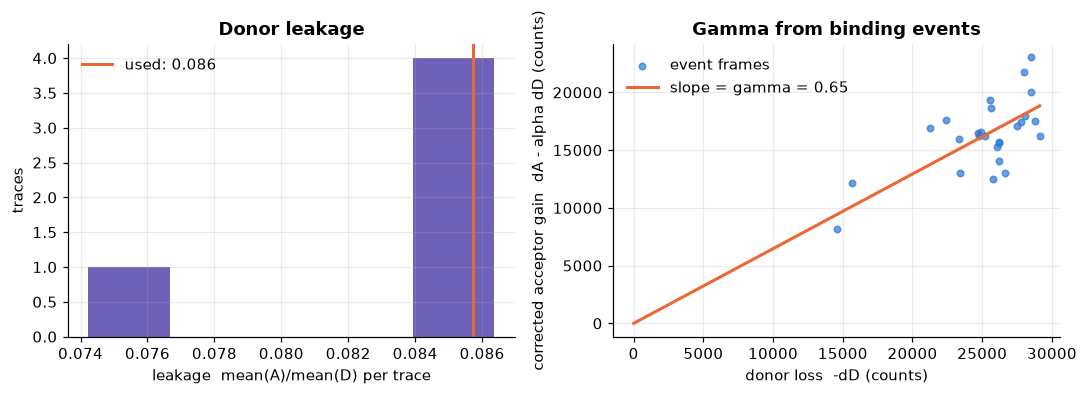

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
if len(leak["per_trace"]):
    ax[0].hist(leak["per_trace"], bins=min(30, max(5, len(leak["per_trace"]) // 2)), color=C_X, alpha=0.8)
ax[0].axvline(ALPHA, color=C_A, lw=2, label=f"used: {ALPHA:.3f}")
ax[0].set(xlabel="leakage  mean(A)/mean(D) per trace", ylabel="traces", title="Donor leakage")
ax[0].legend()
if len(gam["x"]):
    ax[1].scatter(gam["x"], gam["y"], s=18, color=C_D, alpha=0.7, label="event frames")
xx = np.linspace(0, max(gam["x"].max() if len(gam["x"]) else 1, 1), 50)
ax[1].plot(xx, GAMMA * xx, color=C_A, lw=2, label=f"slope = gamma = {GAMMA:.2f}")
ax[1].set(xlabel="donor loss  -dD (counts)", ylabel="corrected acceptor gain  dA - alpha dD (counts)", title="Gamma from binding events")
ax[1].legend()
fig.tight_layout()
fig.savefig(out / "figures" / "leakage_gamma.png", bbox_inches="tight")
plt.show()

## 7. Correct and normalise

`A_corr = A - alpha D`, `D_corr = gamma D`; both divided by the trace's **mean total**
`<A_corr + gamma D>` over usable frames. FRET of any frame/state is `An / (An + Dn)`, which equals
`A_corr / (A_corr + gamma D)`. The HMM observes the 2-D vector `(Dn, An)`, so it uses intensity as well as
ratio information and keeps the anti-correlation between channels.

In [19]:
norm = []     # one dict per accepted trace
for t, p in zip(traces_ok, pps_ok):
    Dn, An, mt = F.correct_and_normalize(t.D, t.A, p.valid, ALPHA, GAMMA)
    segs = F.split_segments(p.valid, MIN_SEGMENT_FRAMES)
    norm.append(dict(trace=t, pp=p, Dn=Dn, An=An, mean_total=mt, segs=segs))

X_all = np.vstack([np.column_stack([n["Dn"][s:e], n["An"][s:e]]) for n in norm for s, e in n["segs"]])
lengths_all = [e - s for n in norm for s, e in n["segs"]]
print(f"{len(lengths_all)} contiguous segments, {len(X_all)} frames go into the global HMM")

5 contiguous segments, 2610 frames go into the global HMM


## 8. Global 5-state HMM

Full-covariance 2-D Gaussian emissions on `(Dn, An)`, all segments of all traces fitted together.
Starting values: state 0 = donor-only cloud, the other states at quantiles of the FRET distribution of the
remaining frames (binding is rare, so plain k-means would place every centre inside the donor-only cloud).
States are sorted by FRET. A state is **acceptor-bound** if its FRET exceeds the FRET of the lowest
(donor-only / background) state by `BOUND_MARGIN`.

In [20]:
g = F.fit_global_hmm(X_all, lengths_all, N_STATES, n_iter=GLOBAL_MAX_ITER)
E_BG = float(F.state_fret(g.means_)[0])
E_THR = E_BG + BOUND_MARGIN
states_global = F.state_table(g, E_THR)
print(f"converged: {g.converged_}   log-likelihood: {g.loglik_:.1f}")
print(f"background FRET = {E_BG:.3f}  ->  bound if FRET > {E_THR:.3f}")
states_global.round(3)

converged: True   log-likelihood: 7068.1
background FRET = -0.012  ->  bound if FRET > 0.088


,state,Dn,An,FRET,sd_Dn,sd_An,self_transition,bound
0,0,0.972,-0.012,-0.012,0.054,0.063,0.979,False
1,1,1.054,0.003,0.003,0.059,0.068,0.973,False
2,2,0.838,0.214,0.204,0.138,0.021,0.000,True
3,3,0.527,0.496,0.485,0.100,0.129,0.303,True
4,4,0.526,0.528,0.501,0.031,0.060,0.943,True


In [21]:
pd.DataFrame(g.transmat_, columns=[f"to {i}" for i in range(N_STATES)],
             index=[f"from {i}" for i in range(N_STATES)]).round(4)

,to 0,to 1,to 2,to 3,to 4
from 0,0.9794,0.0161,0.0037,0.0009,0.0000
from 1,0.0242,0.9732,0.0000,0.0026,0.0000
from 2,0.8542,0.0000,0.0000,0.1458,0.0000
from 3,0.2927,0.1246,0.1383,0.3032,0.1412
from 4,0.0570,0.0000,0.0000,0.0000,0.9430


## 9. Individual HMM fits

Each trace is re-fitted from the global parameters (all state means, covariances, transition and start
probabilities). A weak MAP prior (`PRIOR_STRENGTH` pseudo-frames) keeps states that never occur in a trace from
drifting onto noise; if a fit fails the global model is used for that trace and it is flagged. The same absolute
FRET threshold is applied to every trace's fitted states, then Viterbi paths give the bound/unbound call.

In [22]:
frame_tables, bound_paths, trace_rows, indiv_states = [], [], [], []
for n in norm:
    t, p = n["trace"], n["pp"]
    Xs = [np.column_stack([n["Dn"][s:e], n["An"][s:e]]) for s, e in n["segs"]]
    if not Xs:
        trace_rows.append(dict(trace=t.name, fit_ok=False, n_fit_frames=0))
        continue
    L = [len(x) for x in Xs]
    model, ok = F.fit_individual_hmm(np.vstack(Xs), L, g, prior_strength=PRIOR_STRENGTH,
                                     n_iter=INDIVIDUAL_MAX_ITER)
    sE = F.state_fret(model.means_)
    bound_state = sE > E_THR
    paths = F.viterbi_segments(model, np.vstack(Xs), L)
    pos = 0
    for (s, e), x in zip(n["segs"], Xs):
        st = paths[pos:pos + len(x)]
        pos += len(x)
        b = bound_state[st]
        bound_paths.append((t.name, s, b))
        frame_tables.append(pd.DataFrame(dict(
            trace=t.name, pair=t.pair, frame=np.arange(s, e), Dn=x[:, 0], An=x[:, 1], FRET=F.frame_fret(x[:, 0], x[:, 1]),
            state=st, state_FRET=sE[st], bound=b)))
    for k in range(N_STATES):
        indiv_states.append(dict(trace=t.name, pair=t.pair, state=k, FRET=sE[k], occupancy=float(np.mean(np.concatenate(
            [paths[sum(L[:i]):sum(L[:i + 1])] for i in range(len(L))]) == k))))
    trace_rows.append(dict(trace=t.name, fit_ok=ok, n_fit_frames=int(sum(L))))

frames = pd.concat(frame_tables, ignore_index=True)
dwells = F.extract_dwells(bound_paths)

summary = qc[qc.accepted].reset_index(drop=True).merge(pd.DataFrame(trace_rows), on="trace", how="left")
summary["mean_total_counts"] = [n["mean_total"] for n in norm]
per_trace = frames.groupby("trace").agg(bound_frames=("bound", "sum"), frames_fit=("bound", "size"))
summary = summary.merge(per_trace, on="trace", how="left")
summary["n_bound_events"] = summary.trace.map(dwells[dwells.bound].groupby("trace").size()).fillna(0).astype(int)
summary["bound_fraction"] = summary.bound_frames / summary.frames_fit
print(f"individual fits ok: {int(summary.fit_ok.sum())} / {len(summary)}")
summary.round(3)

individual fits ok: 5 / 5


,trace,pair,status,accepted,n_frames,n_valid,bleach_frame,n_blinks,blink_frames,bright_level,noise,fit_ok,n_fit_frames,mean_total_counts,bound_frames,frames_fit,n_bound_events,bound_fraction
0,Traces_Ch_3_1_001_tif_pair19,19,ok,True,1200,808,809,0,0,65314.265,3028.702,True,808,38640.954,1,808,1,0.001
1,Traces_Ch_3_1_001_tif_pair86,86,ok,True,1200,750,751,0,0,53034.730,2572.667,True,750,31690.900,6,750,5,0.008
2,Traces_Ch_3_1_001_tif_pair87,87,ok,True,1200,281,282,0,0,52310.382,2109.293,True,281,31388.897,2,281,1,0.007
3,Traces_Ch_3_1_001_tif_pair94,94,ok,True,1200,490,491,0,0,51803.304,2271.789,True,490,31287.555,21,490,3,0.043
4,Traces_Ch_3_1_001_tif_pair123,123,ok,True,1200,281,282,0,0,52097.636,2228.806,True,281,30996.368,3,281,1,0.011


### Example traces
Top: raw donor/acceptor with excluded frames shaded (grey = blink, red = after photobleaching).
Bottom: corrected, normalised signals with frames the HMM calls **acceptor-bound** shaded green.

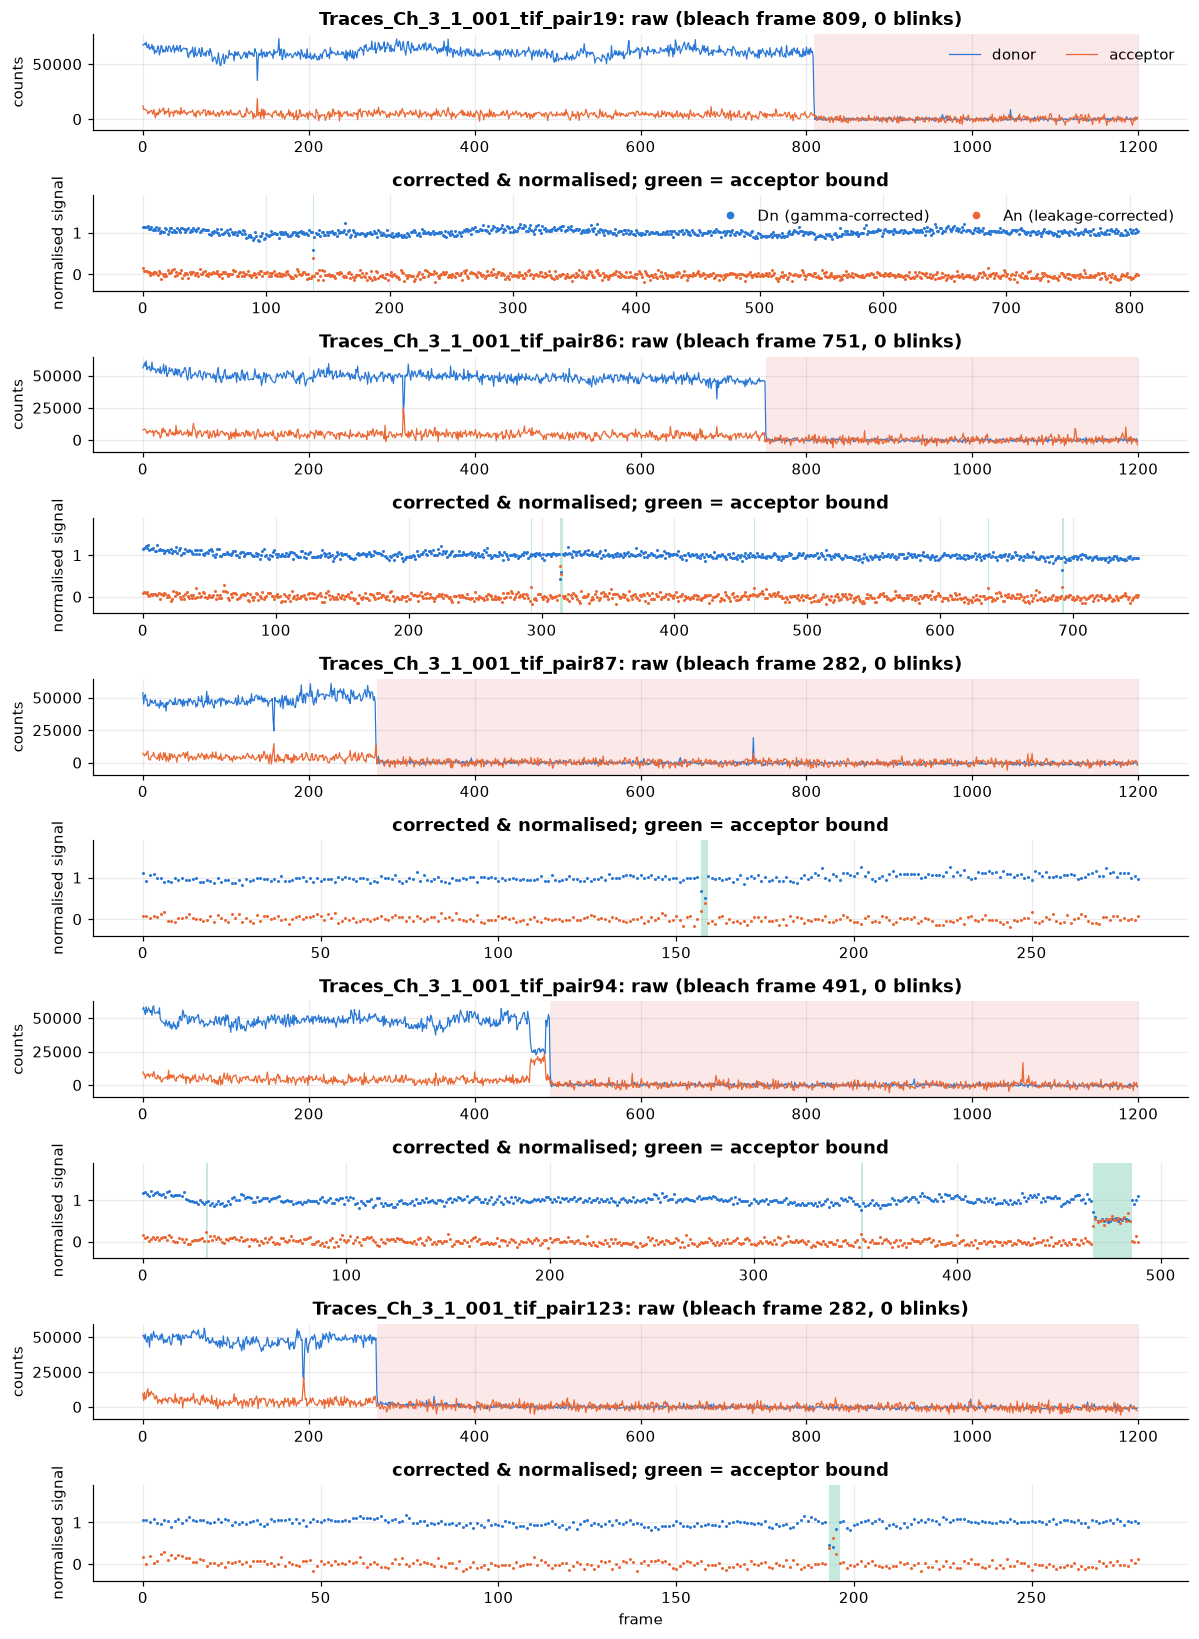

In [23]:
sel = norm[:N_EXAMPLE_TRACES]
fig, axes = plt.subplots(2 * len(sel), 1, figsize=(11, 3.0 * len(sel)), sharex=False)
axes = np.atleast_1d(axes)
for i, n in enumerate(sel):
    t, p = n["trace"], n["pp"]
    a0, a1 = axes[2 * i], axes[2 * i + 1]
    fr = np.arange(t.n_frames)
    a0.plot(fr, t.D, color=C_D, lw=0.8, label="donor")
    a0.plot(fr, t.A, color=C_A, lw=0.8, label="acceptor")
    for s, e in p.blinks:
        a0.axvspan(s, e, color="0.6", alpha=0.35, lw=0)
    if p.bleach_frame is not None:
        a0.axvspan(p.bleach_frame, t.n_frames, color="#e34948", alpha=0.12, lw=0)
    a0.set(ylabel="counts", title=f"{t.name}: raw (bleach frame {p.bleach_frame}, {len(p.blinks)} blinks)")
    a1.plot(fr[p.valid], n["Dn"][p.valid], ".", ms=2, color=C_D, label="Dn (gamma-corrected)")
    a1.plot(fr[p.valid], n["An"][p.valid], ".", ms=2, color=C_A, label="An (leakage-corrected)")
    ft = frames[frames.trace == t.name]
    for s, e in F.find_runs(np.isin(fr, ft.frame[ft.bound])):
        a1.axvspan(s, e, color=C_BOUND, alpha=0.25, lw=0)
    a1.set(ylabel="normalised signal", ylim=(-0.4, 1.9), title="corrected & normalised; green = acceptor bound")
    if i == 0:
        a0.legend(loc="upper right", ncol=2)
        a1.legend(loc="upper right", ncol=2, markerscale=4)
axes[-1].set_xlabel("frame")
fig.tight_layout()
fig.savefig(out / "figures" / "example_traces.png", bbox_inches="tight")
plt.show()

## 10. Acceptor dwell times: 1- vs 2-component rate models

A *bound dwell* is an uninterrupted Viterbi run in a bound state. Dwells that touch the end of a usable
segment are **right-censored** (the acceptor was still bound when bleaching, a blink or the end of the movie
cut the observation) and enter the likelihood through the survival function; dwells that begin at the start of
a segment are left-censored and dropped from the bound-dwell fit. Times are quantised to frames; the likelihood
uses `P(n frames) = S((n-1)dt) - S(n dt)` with `S(t) = sum_i w_i exp(-k_i t)`.
Models are compared with AIC/BIC (lower is better). The **unbound** dwell fit (time to binding) is shown too;
there left-censored dwells are kept as censored observations (memoryless approximation) because most traces
contain no binding event at all.

In [24]:
def dwell_fits(kind):
    d = dwells[dwells.bound == (kind == "bound")]
    if kind == "bound":
        d = d[~d.left_censored]
        cens = d.right_censored.to_numpy()
    else:
        cens = (d.right_censored | d.left_censored).to_numpy()
    n = d.n_frames.to_numpy()
    res = {}
    if (~cens).sum() < 2:
        return d, n, cens, res
    for nc in (1, 2):
        r = F.fit_dwell_model(n, cens, FRAME_TIME_S, nc, seed=SEED)
        if N_BOOT:
            bs = F.bootstrap_dwell_model(n, cens, FRAME_TIME_S, nc, n_boot=N_BOOT, seed=SEED)
            r["boot"] = bs
        res[nc] = r
    return d, n, cens, res


def fit_table(kind, res):
    rows = []
    for nc, r in res.items():
        row = dict(dwell_type=kind, model=f"{nc}-component", n_dwells=r["n_dwells"], n_censored=r["n_censored"],
                   loglik=r["loglik"], AIC=r["aic"], BIC=r["bic"], mean_dwell_s=r["mean_dwell"])
        for i, (k, w) in enumerate(zip(r["rates"], r["weights"]), 1):
            row[f"k{i} (1/s)"], row[f"w{i}"] = k, w
            if "boot" in r and len(r["boot"]):
                lo, hi = np.percentile(r["boot"][f"k{i}"], [2.5, 97.5])
                row[f"k{i} 95% CI"] = f"[{lo:.3g}, {hi:.3g}]"
        rows.append(row)
    return pd.DataFrame(rows)


dwell_results = {kind: dwell_fits(kind) for kind in ("bound", "unbound")}
fit_tables = pd.concat([fit_table(k, v[3]) for k, v in dwell_results.items() if v[3]], ignore_index=True)
fit_tables

,dwell_type,model,n_dwells,n_censored,loglik,AIC,BIC,mean_dwell_s,k1 (1/s),w1,k1 95% CI,k2 (1/s),w2,k2 95% CI
0,bound,1-component,11,0,-21.004968,44.009935,44.407830,2.466304,4.054651e-01,1.000000,"[0.142, 1.87]",NaN,NaN,NaN
1,bound,2-component,11,0,-15.422200,36.844400,38.038086,2.406747,6.756645e-02,0.116413,"[0.0613, 1.55]",1.292154,0.883587,"[0.782, 10]"
2,unbound,1-component,16,10,-42.345385,86.690769,87.463358,427.331414,2.340104e-03,1.000000,"[0.000764, 0.00484]",NaN,NaN,NaN
3,unbound,2-component,16,10,-42.224224,90.448449,92.766215,522279.453523,3.880481e-07,0.202580,"[2.65e-07, 0.00481]",0.003449,0.797420,"[0.00116, 0.0327]"


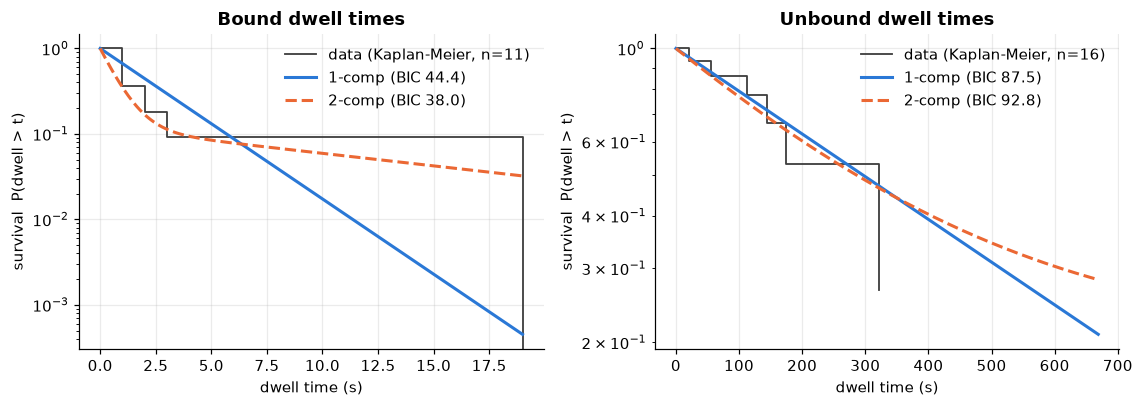

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
for ax, kind in zip(axes, ("bound", "unbound")):
    d, n, cens, res = dwell_results[kind]
    ax.set(title=f"{kind.capitalize()} dwell times", xlabel="dwell time (s)", ylabel="survival  P(dwell > t)", yscale="log")
    if not res:
        ax.text(0.5, 0.5, "too few dwells to fit", transform=ax.transAxes, ha="center")
        continue
    tk, sk = F.kaplan_meier(n, cens, FRAME_TIME_S)
    ax.step(np.r_[0, tk], np.r_[1, sk], where="post", color="0.25", lw=1.2, label=f"data (Kaplan-Meier, n={len(n)})")
    tt = np.linspace(0, max(n.max() * FRAME_TIME_S, FRAME_TIME_S), 300)
    for nc, col in ((1, C_D), (2, C_A)):
        r = res[nc]
        ax.plot(tt, F.model_survival_curve(r, tt), color=col, lw=2, ls="-" if nc == 1 else "--",
                label=f"{nc}-comp (BIC {r['bic']:.1f})")
    ax.legend()
fig.tight_layout()
fig.savefig(out / "figures" / "dwell_times.png", bbox_inches="tight")
plt.show()

## 11. FRET histogram of acceptor-bound frames and Gaussian mixture

Frame-level FRET `An / (An + Dn)` of all frames the HMM calls bound, fitted with a 1-D Gaussian mixture
(components chosen by BIC unless `GMM_N_COMPONENTS` is set).

In [26]:
bound_E = frames.loc[frames.bound, "FRET"].to_numpy()
bound_E = bound_E[np.isfinite(bound_E)]
print(f"{len(bound_E)} bound frames from {frames[frames.bound].trace.nunique()} traces")
gmm, gmm_bic = F.fit_gmm_1d(bound_E, GMM_MAX_COMPONENTS, GMM_N_COMPONENTS, seed=SEED)
gmm_bic

33 bound frames from 5 traces


,n_components,BIC,AIC,loglik
0,1,-31.294536,-34.287551,19.143776
1,2,-51.386376,-58.868914,34.434457
2,3,-47.979254,-59.951314,37.975657


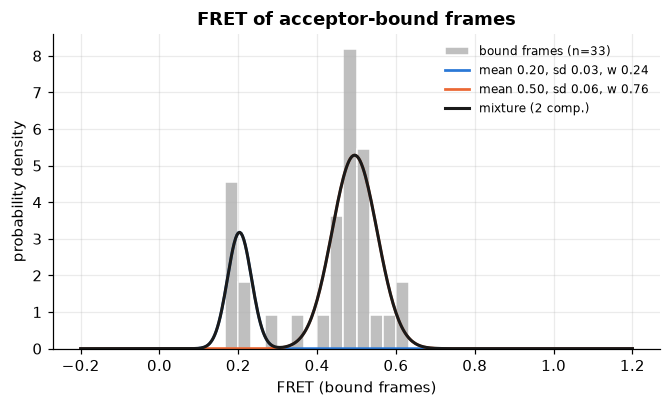

,mean,sd,weight
0,0.203,0.030,0.242
1,0.495,0.057,0.758


In [27]:
fig, ax = plt.subplots(figsize=(6.2, 3.8))
bins = np.linspace(-0.2, 1.2, 43)
ax.hist(bound_E, bins=bins, density=True, color="0.75", edgecolor="white", label=f"bound frames (n={len(bound_E)})")
gmm_table = pd.DataFrame()
if gmm is not None:
    xs = np.linspace(-0.2, 1.2, 400)
    order = np.argsort(gmm.means_.ravel())
    from scipy.stats import norm as _norm
    palette = [C_D, C_A, C_OK, C_X]
    for j, k in enumerate(order):
        mu, sd, w = gmm.means_[k, 0], np.sqrt(gmm.covariances_[k, 0, 0]), gmm.weights_[k]
        ax.plot(xs, w * _norm.pdf(xs, mu, sd), color=palette[j % 4], lw=1.8, label=f"mean {mu:.2f}, sd {sd:.2f}, w {w:.2f}")
    ax.plot(xs, np.exp(gmm.score_samples(xs[:, None])), color="0.1", lw=2, label=f"mixture ({gmm.n_components} comp.)")
    gmm_table = pd.DataFrame(dict(mean=gmm.means_.ravel()[order], sd=np.sqrt(gmm.covariances_[:, 0, 0])[order],
                                  weight=gmm.weights_[order]))
ax.set(xlabel="FRET (bound frames)", ylabel="probability density", title="FRET of acceptor-bound frames")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(out / "figures" / "bound_fret_gmm.png", bbox_inches="tight")
plt.show()
gmm_table.round(3)

## 12. Save results

In [28]:
summary.to_csv(out / "trace_summary.csv", index=False)
qc.to_csv(out / "photophysics_qc.csv", index=False)
states_global.to_csv(out / "hmm_global_states.csv", index=False)
pd.DataFrame(indiv_states).to_csv(out / "hmm_individual_states.csv", index=False)
dwells.to_csv(out / "dwells.csv", index=False)
fit_tables.to_csv(out / "dwell_model_fits.csv", index=False)
gmm_table.to_csv(out / "bound_fret_gmm.csv", index=False)
frames.to_csv(out / "frames.csv.gz", index=False)
with open(out / "parameters_used.json", "w") as fh:
    json.dump(dict(leakage=ALPHA, leakage_estimated=bool(leak["estimated"]), gamma=GAMMA,
                   gamma_estimated=bool(gam["estimated"]), gamma_ci=list(map(float, gam["ci"])),
                   n_binding_events_for_gamma=int(gam["n_events"]), background_fret=E_BG,
                   bound_fret_threshold=E_THR, frame_time_s=FRAME_TIME_S, n_traces=len(traces),
                   n_traces_accepted=len(traces_ok)), fh, indent=2)
print("saved to", out.resolve())
sorted(p.name for p in out.iterdir())

saved to /tmp/claude-0/-home-user-20261001-FRET-colocalization/a094ad41-b2f3-546f-beb1-29759f758601/scratchpad/run5/results


['bound_fret_gmm.csv',
 'dwell_model_fits.csv',
 'dwells.csv',
 'figures',
 'frames.csv.gz',
 'hmm_global_states.csv',
 'hmm_individual_states.csv',
 'parameters_used.json',
 'photophysics_qc.csv',
 'trace_summary.csv']

## Notes and limitations

* **Donor excitation only.** Without direct acceptor excitation, *acceptor* photobleaching or blinking while bound is
  indistinguishable from dissociation, so it shortens the apparent bound dwell time (bound dwells are therefore lower
  bounds on residence time). Donor bleaching/blinking is caught from the collapse of the total signal.
* **Leakage** here also absorbs any direct acceptor excitation by the donor laser (same signature when only donor
  excitation is used). It is estimated from acceptor-free frames and assumes the background subtraction left no offset.
* **Gamma and leakage are global** (pooled over traces); with few traces/events the defaults 0.09 / 0.7 are used and
  the printout in section 5 says so. With the 5 example traces both are estimated (6 events), giving values close to
  the defaults.
* **Dwell times** are limited by the frame time; most example events last 1-3 frames, so rates close to
  `1/FRAME_TIME_S` are at the resolution limit. Set `FRAME_TIME_S` to the exposure time to get rates in 1/s.
* Few bound dwells make the 2-component model poorly determined; use the BIC, the bootstrap CIs, and the number of dwells
  reported before interpreting a second component.